# LSTM with daily sentiment + fundamentals-style features

This notebook extends the univariate setup in `LSTMModel1.ipynb`:

1. **One row per trading/calendar day** with engineered columns.
2. **LSTM input** is shape `(batch, time_steps, n_features)` — each time step is a vector `[Close, …]` (all scaled using training data only).
3. **Multi-task target (Section 4.3)**: (a) next-step **Close** — regression with MSE; (b) **direction** — binary label `y_t = 1[Δ log p_{t+1} > 0]` with `BCEWithLogitsLoss`. **Combined loss** `L = α·MSE + (1−α)·BCE` (tune `LOSS_ALPHA`). Shared trunk + separate heads.
4. **Split**: chronological **70% / 15% / 15%** train / validation / test on the panel (no shuffle). Validation is a contiguous calendar block (not a tail of train sequences).
5. **Metrics**: regression — MAE, RMSE, MAPE, R², directional accuracy from predicted level vs previous close; classification — accuracy, F1, AUC-ROC, confusion matrix vs the log-return sign label.
6. **Sweep `TIME_STEPS`** to compare history length (same split).

**FinBERT teammate notebook** (`finBert_commodity_pipeline_organized (1).ipynb`): after the merge cell it saves `data/processed/merged_for_lstm.csv`. Set `USE_FINBERT_MERGED = True` in the next cell to load that file (daily `price` + FinBERT aggregates, including mean `topic_score` as `topic_confidence_mean`).

Otherwise set `USE_FINBERT_MERGED = False` and use `PRICE_CSV` + `NEWS_CSV`, or rely on synthetic fallback when those files are missing.

**Note:** Strong scores depend on data size and signal; this setup matches the report’s multi-task design so you can tune `LOSS_ALPHA`, `TIME_STEPS`, and epochs. Class-imbalance uses `pos_weight` on the direction loss.

Comments follow the same style as `LSTMModel1.ipynb`: short `#Title case` line comments before each block, plus end-of-line notes on important steps (split, normalise, forward/backward pass, plots).


In [17]:
# Homebrew/system Python is PEP 668 "externally managed": `%pip install` into that kernel will error.
# Use kernel **Python (ds-project-g8)** (this repo's `.venv`). One-time setup from repo root in Terminal:
#   python3 -m venv .venv && .venv/bin/python -m pip install -U pip && .venv/bin/python -m pip install -r requirements.txt && .venv/bin/python -m ipykernel install --user --name=ds_project_g8 --display-name="Python (ds-project-g8)"
# Then choose that kernel here, Restart, and run the imports cell.
from pathlib import Path
import sys

if ".venv" not in Path(sys.executable).parts:
    raise RuntimeError(
        "Select Jupyter kernel 'Python (ds-project-g8)' (project .venv). "
        f"Current interpreter: {sys.executable}"
    )

In [18]:
#Imports: pandas/numpy for the panel, torch for the LSTM, sklearn scaler and metrics, matplotlib for plots (same idea as LSTMModel1)
# Use torch 2.5.x from repo `requirements.txt` — PyTorch 2.11 + Jupyter often breaks inside torch._dynamo on import.
import os
from pathlib import Path


def _project_root() -> Path:
    """Jupyter often uses cwd = notebooks/; data/processed is next to notebooks at repo root."""
    here = Path.cwd().resolve()
    for base in (here, here.parent, here.parent.parent):
        if (base / "data" / "processed" / "merged_for_lstm.csv").is_file():
            return base
    return here.parent if here.name == "notebooks" else here


_REPO_ROOT = _project_root()

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
)
import matplotlib.pyplot as plt

#Primary input: merged CSV from teammate FinBERT notebook (daily sentiment + price)
USE_FINBERT_MERGED = True
FINBERT_MERGED_CSV = os.environ.get(
    "FINBERT_MERGED_CSV",
    str(_REPO_ROOT / "data" / "processed" / "merged_for_lstm.csv"),
)

#Fallback: separate price file and article-level news CSV if FinBERT export is missing (paths relative to repo root)
_p = os.environ.get("PRICE_CSV", "prices.csv")
PRICE_CSV = _p if os.path.isabs(_p) else str(_REPO_ROOT / _p)
_n = os.environ.get("NEWS_CSV", "news_sentiment.csv")
NEWS_CSV = _n if os.path.isabs(_n) else str(_REPO_ROOT / _n)

#Reproducibility (same seed idea as LSTMModel1)
RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)


In [19]:
#Build the daily panel: one row per date, columns = features the LSTM sees (Close + sentiment + lags + vol + placeholders)


def load_or_synth_prices(path: str, n: int = 1200) -> pd.DataFrame:
    """Load date, Close from CSV; if file missing, simulate GBM prices like LSTMModel1."""
    if os.path.isfile(path):
        p = pd.read_csv(path)
        p["date"] = pd.to_datetime(p["date"])
        return p.sort_values("date").reset_index(drop=True)
    #Synthetic GBM path when no CSV (drift, vol, initial price, one trading-day step)
    mu, sigma, S0, dt = 0.05, 0.2, 100.0, 1 / 252
    prices = np.zeros(n)
    prices[0] = S0
    for t in range(1, n):
        r = np.random.normal(mu * dt, sigma * np.sqrt(dt))
        prices[t] = prices[t - 1] * (1 + r)
    d0 = pd.Timestamp("2020-01-01")
    return pd.DataFrame({"date": d0 + pd.to_timedelta(np.arange(n), unit="D"), "Close": prices})


def load_or_synth_news(price_df: pd.DataFrame, path: str) -> pd.DataFrame:
    """Article rows: date, sentiment, optional topic_confidence or topic_score (FinBERT naming)."""
    if os.path.isfile(path):
        n = pd.read_csv(path)
        n["date"] = pd.to_datetime(n["date"]).dt.normalize()
        return n
    #Synthetic headlines on random days (only for testing the pipeline without real news)
    rng = np.random.default_rng(RANDOM_SEED)
    days = price_df["date"].dt.normalize().unique()
    rows = []
    for d in days:
        if rng.random() < 0.35:
            k = int(rng.integers(1, 6))
            for _ in range(k):
                rows.append(
                    {
                        "date": pd.Timestamp(d),
                        "sentiment": float(rng.normal(0, 0.4)),
                        "topic_confidence": float(rng.uniform(0.3, 1.0)),
                    }
                )
    return pd.DataFrame(rows)


def daily_news_features(news: pd.DataFrame) -> pd.DataFrame:
    #Aggregate many headlines per calendar day into one row (mean sentiment, std, count, topic mean)
    if news.empty:
        return pd.DataFrame(columns=["date", "avg_sentiment", "sentiment_std", "news_volume", "topic_confidence_mean"])
    agg = {
        "avg_sentiment": ("sentiment", "mean"),
        "sentiment_std": ("sentiment", "std"),
        "news_volume": ("sentiment", "count"),
    }
    if "topic_confidence" in news.columns:
        agg["topic_confidence_mean"] = ("topic_confidence", "mean")
    elif "topic_score" in news.columns:
        agg["topic_confidence_mean"] = ("topic_score", "mean")
    g = news.groupby("date", as_index=False).agg(**agg)
    if "topic_confidence_mean" not in g.columns:
        g["topic_confidence_mean"] = np.nan
    g["sentiment_std"] = g["sentiment_std"].fillna(0.0)
    return g


def panel_from_finbert_merged_csv(path: str):
    """Read merged_for_lstm.csv: FinBERT daily aggregates already aligned with price (column price renamed to Close)."""
    df = pd.read_csv(path)
    df["date"] = pd.to_datetime(df["date"]).dt.normalize()
    if "Close" not in df.columns and "price" in df.columns:
        df = df.rename(columns={"price": "Close"})
    required = ["avg_sentiment", "sentiment_std", "news_volume"]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"merged_for_lstm.csv missing columns {missing}. Re-run FinBERT through merge (and daily aggregation).")
    if "topic_confidence_mean" not in df.columns:
        df["topic_confidence_mean"] = 0.0
    df["topic_confidence_mean"] = df["topic_confidence_mean"].fillna(0.0)

    #Return today, lagged return yesterday, 7-day vol known at open (shift so we do not peek at same close)
    df["return_1"] = df["Close"].pct_change()
    df["return_lag1"] = df["return_1"].shift(1)
    df["rolling_vol_7"] = df["return_1"].rolling(7).std().shift(1)

    if "inventory_draw" not in df.columns:
        df["inventory_draw"] = 0.0
    if "production_cut" not in df.columns:
        df["production_cut"] = 0.0
    df["inventory_draw_count"] = df["inventory_draw"].astype(float)
    df["production_cut_count"] = df["production_cut"].astype(float)

    feat_cols = [
        "Close",
        "avg_sentiment",
        "sentiment_std",
        "news_volume",
        "topic_confidence_mean",
        "return_lag1",
        "rolling_vol_7",
        "inventory_draw_count",
        "production_cut_count",
    ]
    #Drop warm-up rows where lag or rolling vol is NaN
    df = df.dropna(subset=["return_lag1", "rolling_vol_7"]).reset_index(drop=True)
    return df, feat_cols


def build_feature_table(price_df: pd.DataFrame, news: pd.DataFrame):
    #Left join news aggregates onto full price calendar; missing news days become neutral zeros
    df = price_df.copy()
    df["date"] = pd.to_datetime(df["date"]).dt.normalize()
    daily = daily_news_features(news)
    df = df.merge(daily, on="date", how="left")
    df["avg_sentiment"] = df["avg_sentiment"].fillna(0.0)
    df["sentiment_std"] = df["sentiment_std"].fillna(0.0)
    df["news_volume"] = df["news_volume"].fillna(0).astype(float)
    df["topic_confidence_mean"] = df["topic_confidence_mean"].fillna(0.0)

    df["return_1"] = df["Close"].pct_change()
    df["return_lag1"] = df["return_1"].shift(1)
    df["rolling_vol_7"] = df["return_1"].rolling(7).std().shift(1)

    if "inventory_draw" not in df.columns:
        df["inventory_draw"] = 0.0
    if "production_cut" not in df.columns:
        df["production_cut"] = 0.0
    df["inventory_draw_count"] = df["inventory_draw"].astype(float)
    df["production_cut_count"] = df["production_cut"].astype(float)

    feat_cols = [
        "Close",
        "avg_sentiment",
        "sentiment_std",
        "news_volume",
        "topic_confidence_mean",
        "return_lag1",
        "rolling_vol_7",
        "inventory_draw_count",
        "production_cut_count",
    ]
    df = df.dropna(subset=["return_lag1", "rolling_vol_7"]).reset_index(drop=True)
    return df, feat_cols


#Choose data source: FinBERT merged file if present, else synthetic / price + news path
if USE_FINBERT_MERGED and os.path.isfile(FINBERT_MERGED_CSV):
    panel, FEATURE_COLS = panel_from_finbert_merged_csv(FINBERT_MERGED_CSV)
    print("Loaded FinBERT merged:", FINBERT_MERGED_CSV)
else:
    if USE_FINBERT_MERGED:
        print("FinBERT CSV missing — fallback to PRICE_CSV / synthetic:", FINBERT_MERGED_CSV)
    price_df = load_or_synth_prices(PRICE_CSV)
    news_df = load_or_synth_news(price_df, NEWS_CSV)
    panel, FEATURE_COLS = build_feature_table(price_df, news_df)

print(panel.tail(3))
print("Features:", FEATURE_COLS)
print("Panel rows:", len(panel), "| date range:", panel["date"].min(), "→", panel["date"].max())


Loaded FinBERT merged: /Users/mandarjoshi/Desktop/SUTD_Term_6/Computational_Data_Science/ProjectModels/DS_Project_g8/data/processed/merged_for_lstm.csv
          date  avg_sentiment  median_sentiment  sentiment_std  max_sentiment  \
209 2023-08-06       0.339393         -0.171542       0.391324       0.067849   
210 2023-08-07      -0.015921         -0.169000       0.121782       0.137086   
211 2023-08-08      -0.135609          0.149061       0.240090       0.395664   

     min_sentiment  news_volume  sentiment_volume_weighted  \
209      -0.213335            1                   0.036242   
210      -0.050414            8                  -0.149567   
211      -0.482916            4                  -0.115379   

     topic_confidence_mean      Close  return_1  return_lag1  rolling_vol_7  \
209               0.598993  71.066645 -0.002756    -0.000035       0.004836   
210               0.598626  70.762979 -0.004273    -0.002756       0.005139   
211               0.759878  71.836092


=== FinBERT data check (merged CSV ↔ LSTM panel) ===
  avg_sentiment: max |panel − csv| = 0  (should be ~0)
  sentiment_std: max |panel − csv| = 0  (should be ~0)
  news_volume: max |panel − csv| = 0  (should be ~0)
  topic_confidence_mean: max |panel − csv| = 0  (should be ~0)

Correlations (Pearson, panel) — sentiment vs Close / returns:
  avg_sentiment          vs ret_fwd1: +0.0250  vs Close: +0.0290
  sentiment_std          vs ret_fwd1: +0.0621  vs Close: -0.1132
  news_volume            vs ret_fwd1: -0.0630  vs Close: +0.1534
  topic_confidence_mean  vs ret_fwd1: +0.0626  vs Close: +0.0019

Share of days with news_volume > 0: 100.0%
If correlations are ~0, sentiment may still be 'correct' but not predictive of next-day returns.



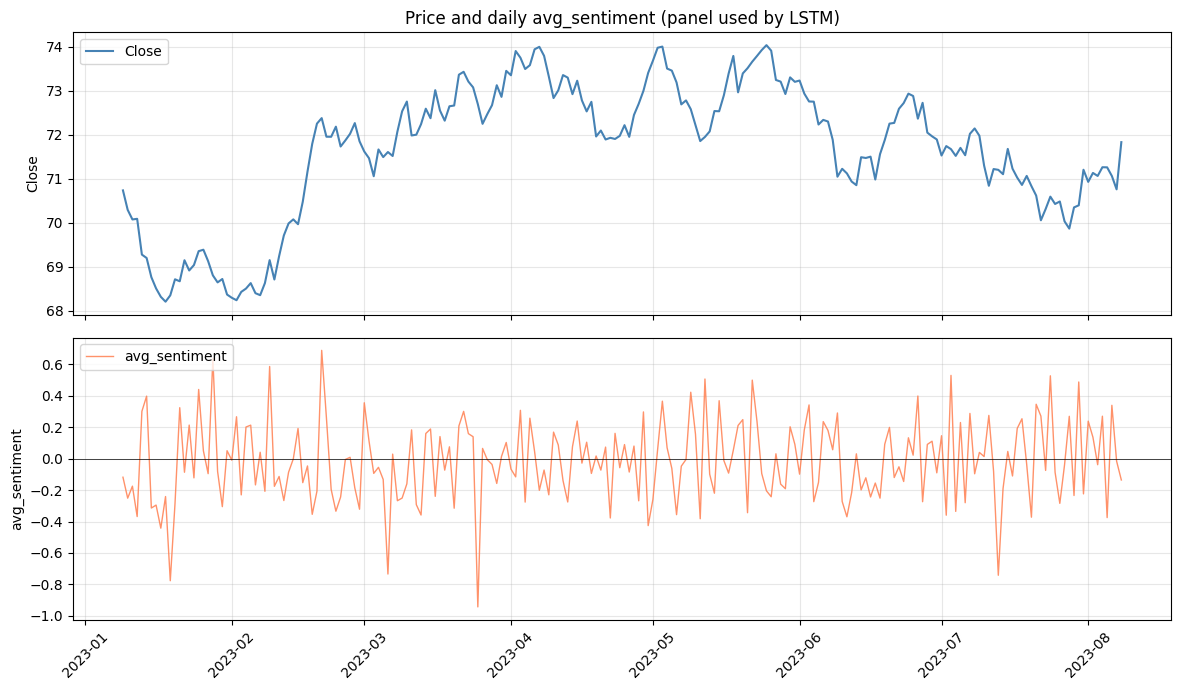

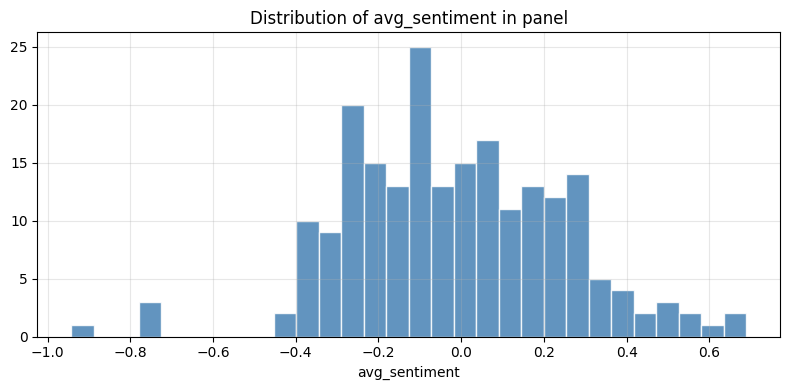

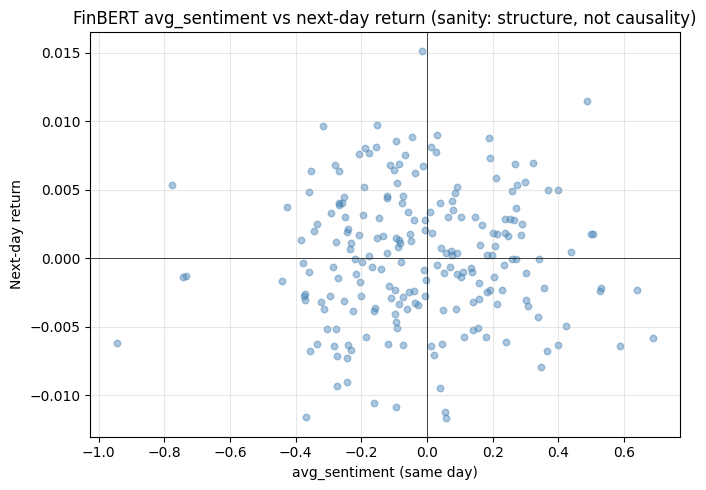

In [20]:
#FinBERT sanity checks and quick plots (verify CSV columns match panel; eyeball sentiment vs price)

SENTINEL_COLS = ["avg_sentiment", "sentiment_std", "news_volume", "topic_confidence_mean"]


def finbert_merge_sanity(merged_csv: str, panel_df: pd.DataFrame) -> None:
    print("\n=== FinBERT data check (merged CSV ↔ LSTM panel) ===")
    if not os.path.isfile(merged_csv):
        print("Skipped: file not found (using synthetic / fallback path).")
        return
    raw = pd.read_csv(merged_csv)
    raw["date"] = pd.to_datetime(raw["date"]).dt.normalize()
    for c in SENTINEL_COLS:
        if c not in raw.columns:
            print(f"WARNING: column '{c}' missing from merged CSV.")
    key = ["date"] + [c for c in SENTINEL_COLS if c in raw.columns and c in panel_df.columns]
    if len(key) < 2:
        print("Not enough overlapping columns to compare.")
        return
    #Inner join on date; compare panel column to CSV column renamed with _csv suffix
    chk = panel_df[key].merge(raw[key].rename(columns={c: f"{c}_csv" for c in key[1:]}), on="date", how="inner")
    if chk.empty:
        print("WARNING: no matching dates between panel and CSV (check date parsing).")
        return
    for c in key[1:]:
        d = (chk[c] - chk[f"{c}_csv"]).abs()
        print(f"  {c}: max |panel − csv| = {d.max():.6g}  (should be ~0)")
    #Pearson correlations: weak values are common; they do not by themselves mean the pipeline is broken
    p = panel_df.copy()
    if "return_1" not in p.columns:
        p["return_1"] = p["Close"].pct_change()
    p["ret_fwd1"] = p["return_1"].shift(-1)
    corr_cols = ["Close", "return_1", "ret_fwd1"] + [c for c in SENTINEL_COLS if c in p.columns]
    cmat = p[corr_cols].corr(numeric_only=True)
    print("\nCorrelations (Pearson, panel) — sentiment vs Close / returns:")
    for c in SENTINEL_COLS:
        if c in cmat.index:
            a = cmat.loc[c, "ret_fwd1"] if "ret_fwd1" in cmat.columns else float("nan")
            b = cmat.loc[c, "Close"] if "Close" in cmat.columns else float("nan")
            sa = f"{a:+.4f}" if pd.notna(a) else "nan"
            sb = f"{b:+.4f}" if pd.notna(b) else "nan"
            print(f"  {c:22s} vs ret_fwd1: {sa}  vs Close: {sb}")
    nz = (p["news_volume"] > 0).mean()
    print(f"\nShare of days with news_volume > 0: {nz:.1%}")
    print("If correlations are ~0, sentiment may still be 'correct' but not predictive of next-day returns.\n")


if USE_FINBERT_MERGED and os.path.isfile(FINBERT_MERGED_CSV):
    finbert_merge_sanity(FINBERT_MERGED_CSV, panel)

#First plot: Close over time and daily avg_sentiment (features the LSTM sees)
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
ax0, ax1 = axes
ax0.plot(panel["date"], panel["Close"], color="steelblue", lw=1.5, label="Close")
ax0.set_ylabel("Close")
ax0.legend(loc="upper left")
ax0.set_title("Price and daily avg_sentiment (panel used by LSTM)")
ax0.grid(True, alpha=0.3)
ax1.plot(panel["date"], panel["avg_sentiment"], color="coral", lw=1, alpha=0.85, label="avg_sentiment")
ax1.axhline(0, color="k", lw=0.5)
ax1.set_ylabel("avg_sentiment")
ax1.legend(loc="upper left")
ax1.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#Second plot: histogram of avg_sentiment (spot stuck-at-zero or odd spikes)
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(panel["avg_sentiment"].dropna(), bins=30, color="steelblue", edgecolor="white", alpha=0.85)
ax.set_title("Distribution of avg_sentiment in panel")
ax.set_xlabel("avg_sentiment")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#Third plot: scatter same-day sentiment vs next-day return (exploratory only)
p2 = panel.copy()
p2["ret_fwd1"] = p2["Close"].pct_change().shift(-1)
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(p2["avg_sentiment"], p2["ret_fwd1"], alpha=0.45, s=22, color="steelblue")
ax.axhline(0, color="k", lw=0.5)
ax.axvline(0, color="k", lw=0.5)
ax.set_xlabel("avg_sentiment (same day)")
ax.set_ylabel("Next-day return")
ax.set_title("FinBERT avg_sentiment vs next-day return (sanity: structure, not causality)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Epoch [10/50] train=0.347434 val=0.319698 lr=1.00e-03
Epoch [20/50] train=0.323369 val=0.317023 lr=1.00e-03
Epoch [30/50] train=0.322855 val=0.314723 lr=1.00e-03
Epoch [40/50] train=0.324301 val=0.312884 lr=1.00e-03
Epoch [50/50] train=0.316667 val=0.313666 lr=1.00e-03
Training complete (best checkpoint restored).
Split 70/15/15 | train_end=148 val_end=180 | TIME_STEPS=10 | α=0.5
Sequences: train=138 val=32 test=32
Regression (level): RMSE=0.5108 MAE=0.4387 MAPE=0.62% R²=0.0907
Direction (from ΔClose vs prev): acc=50.00% (excl. flat actual: 50.00%)
Direction (classifier head vs y=1[Δlog p>0]): acc=65.62% F1=0.267 AUC=0.623
Confusion matrix [actual down, up] × [pred down, up]:
[[19  0]
 [11  2]]


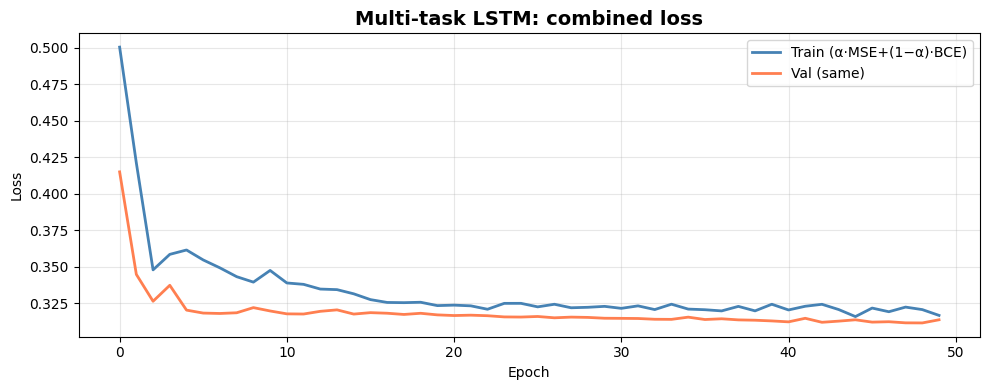

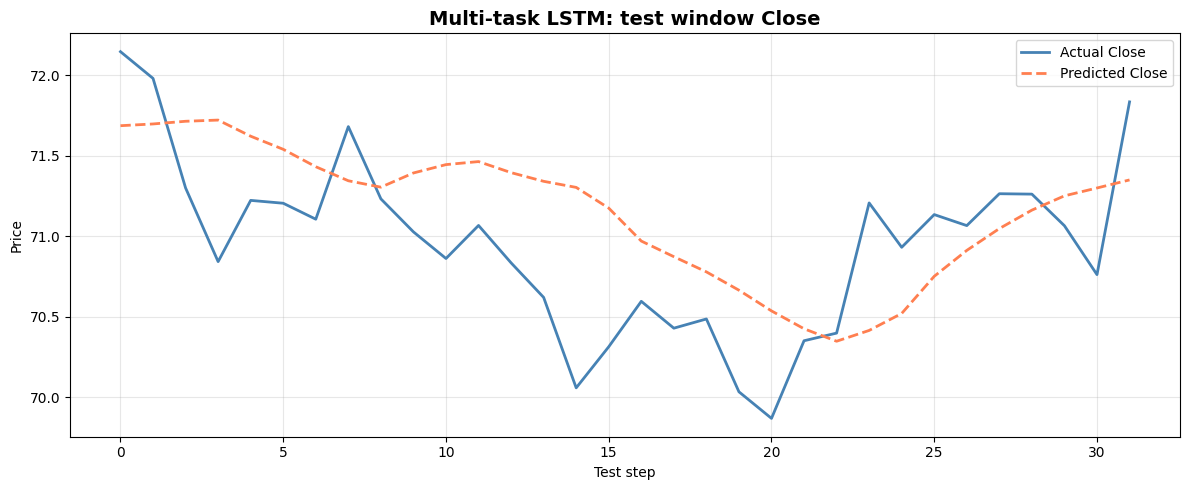

In [21]:
# Multi-task LSTM: shared trunk, price regression head + direction classification head
# Task A: next-day Close (scaled MSE). Task B: y_t = 1[Δ log p_{t+1} > 0] with BCEWithLogitsLoss.
# Combined loss: L = α · MSE + (1 − α) · BCE. Chronological panel split 70% / 15% / 15% (no shuffle).


def _tensor_to_numpy(t):
    t = t.detach().cpu()
    try:
        return t.numpy()
    except Exception:
        return np.array(t.tolist(), dtype=np.float64)


def build_multitask_split(mat, raw_close, time_steps, target_col_idx, i_train_end, i_val_end, n):
    """X windows end the day before target; target day t = i + time_steps (needs t >= 1 for log return)."""

    def pack(i_lo, i_hi_excl):
        X, y_reg, y_cls = [], [], []
        for i in range(i_lo, i_hi_excl):
            t = i + time_steps
            if t < 1 or t >= n:
                continue
            c0, c1 = float(raw_close[t - 1]), float(raw_close[t])
            lr = np.log(max(c1, 1e-12) / max(c0, 1e-12))
            y_cls.append(1.0 if lr > 0 else 0.0)
            X.append(mat[i : i + time_steps])
            y_reg.append(mat[t, target_col_idx])
        return (
            np.array(X, dtype=np.float32),
            np.array(y_reg, dtype=np.float32).reshape(-1, 1),
            np.array(y_cls, dtype=np.float32).reshape(-1, 1),
        )

    tr = pack(0, max(0, i_train_end - time_steps))
    va = pack(i_train_end - time_steps, max(0, i_val_end - time_steps))
    te = pack(i_val_end - time_steps, max(0, n - time_steps))
    return tr, va, te


class MultiTaskLSTM(nn.Module):
    """Shared LSTM (2×64, dropout 0.3); price head linear; direction head small MLP + logit (matches write-up)."""

    def __init__(
        self,
        input_size: int,
        hidden_size: int = 64,
        num_layers: int = 2,
        direction_hidden: int = 16,
        dropout: float = 0.3,
    ):
        super().__init__()
        lstm_dropout = dropout if num_layers > 1 else 0.0
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=lstm_dropout)
        self.dropout = nn.Dropout(dropout)
        self.head_price = nn.Linear(hidden_size, 1)
        self.head_dir_h = nn.Linear(hidden_size, direction_hidden)
        self.head_dir_out = nn.Linear(direction_hidden, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        h = self.dropout(out[:, -1, :])
        price = self.head_price(h)
        z = torch.relu(self.head_dir_h(h))
        z = self.dropout(z)
        dir_logit = self.head_dir_out(z)
        return price, dir_logit


def train_eval_multitask(
    panel: pd.DataFrame,
    feat_cols: list,
    time_steps: int,
    epochs: int = 50,
    batch_size: int = 32,
    lr: float = 1e-3,
    alpha: float = 0.5,
    weight_decay: float = 1e-4,
    early_stop_patience: int = 20,
    scheduler_patience: int = 8,
):
    target_col_idx = feat_cols.index("Close")
    raw = panel[feat_cols].values.astype(np.float64)
    raw_close = panel["Close"].values.astype(np.float64)
    n = len(panel)
    i_train_end = int(n * 0.7)
    i_val_end = int(n * 0.85)
    if i_train_end < 2 or i_val_end <= i_train_end or i_val_end >= n:
        raise ValueError("Panel too short for 70/15/15 split; need more rows.")

    train_raw = raw[:i_train_end]
    time_steps = int(min(time_steps, max(1, i_train_end - 2)))
    scaler_X = MinMaxScaler(feature_range=(0, 1))
    scaler_X.fit(train_raw)
    mat = scaler_X.transform(raw)
    n_feat = raw.shape[1]

    (X_tr, y_tr_reg, y_tr_cls), (X_va, y_va_reg, y_va_cls), (X_te, y_te_reg, y_te_cls) = build_multitask_split(
        mat, raw_close, time_steps, target_col_idx, i_train_end, i_val_end, n
    )
    if len(X_tr) < 1 or len(X_va) < 1 or len(X_te) < 1:
        raise ValueError(
            f"Not enough sequences (train={len(X_tr)}, val={len(X_va)}, test={len(X_te)}); reduce TIME_STEPS."
        )

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    X_train = torch.tensor(X_tr, dtype=torch.float32, device=device)
    y_train_reg = torch.tensor(y_tr_reg, dtype=torch.float32, device=device)
    y_train_cls = torch.tensor(y_tr_cls, dtype=torch.float32, device=device)
    X_val = torch.tensor(X_va, dtype=torch.float32, device=device)
    y_val_reg = torch.tensor(y_va_reg, dtype=torch.float32, device=device)
    y_val_cls = torch.tensor(y_va_cls, dtype=torch.float32, device=device)
    X_test = torch.tensor(X_te, dtype=torch.float32, device=device)
    y_test_reg = torch.tensor(y_te_reg, dtype=torch.float32, device=device)
    y_test_cls = torch.tensor(y_te_cls, dtype=torch.float32, device=device)

    n_pos = float(y_train_cls.sum().item())
    n_neg = float(len(y_train_cls) - n_pos)
    pos_weight = torch.tensor([n_neg / max(n_pos, 1.0)], device=device)

    model = MultiTaskLSTM(input_size=len(feat_cols)).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt, mode="min", factor=0.5, patience=scheduler_patience, min_lr=1e-6
    )
    mse = nn.MSELoss()
    bce = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    train_loader = DataLoader(
        TensorDataset(X_train, y_train_reg, y_train_cls), batch_size=batch_size, shuffle=False
    )

    def invert_close(col_scaled):
        pad = np.zeros((len(col_scaled), n_feat))
        pad[:, target_col_idx] = col_scaled.ravel()
        return scaler_X.inverse_transform(pad)[:, target_col_idx].reshape(-1, 1)

    train_losses, val_losses = [], []
    best_val = float("inf")
    best_state = None
    bad_epochs = 0

    for ep in range(epochs):
        model.train()
        epoch_loss = 0.0
        for xb, yb_reg, yb_cls in train_loader:
            opt.zero_grad()
            pr, lg = model(xb)
            loss = alpha * mse(pr, yb_reg) + (1.0 - alpha) * bce(lg, yb_cls)
            loss.backward()
            opt.step()
            epoch_loss += loss.item() * len(xb)
        tr = epoch_loss / max(1, len(X_train))
        train_losses.append(tr)

        model.eval()
        with torch.no_grad():
            pr_v, lg_v = model(X_val)
            vl = (alpha * mse(pr_v, y_val_reg) + (1.0 - alpha) * bce(lg_v, y_val_cls)).item()
        val_losses.append(vl)
        sched.step(vl)

        if vl + 1e-9 < best_val:
            best_val = vl
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            bad_epochs = 0
        else:
            bad_epochs += 1

        if (ep + 1) % 10 == 0:
            print(f"Epoch [{ep+1}/{epochs}] train={tr:.6f} val={vl:.6f} lr={opt.param_groups[0]['lr']:.2e}")
        if bad_epochs >= early_stop_patience:
            print(f"Early stopping at epoch {ep+1} (best val={best_val:.6f})")
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    model.to(device)
    print("Training complete (best checkpoint restored).")

    model.eval()
    with torch.no_grad():
        pred_s, logit_s = model(X_test)
        pred_s = _tensor_to_numpy(pred_s).reshape(-1, 1)
        logit_s = _tensor_to_numpy(logit_s).reshape(-1, 1)
    y_true_s = _tensor_to_numpy(y_test_reg)
    y_cls_true = _tensor_to_numpy(y_test_cls).ravel()
    prob = 1.0 / (1.0 + np.exp(-logit_s.ravel()))
    y_cls_pred = (prob >= 0.5).astype(np.float64)

    act_price = invert_close(y_true_s)
    pred_price = invert_close(pred_s)

    rmse = float(np.sqrt(mean_squared_error(act_price, pred_price)))
    mae = float(mean_absolute_error(act_price, pred_price))
    r2 = float(r2_score(act_price, pred_price))
    eps = 1e-9
    mape = float(np.mean(np.abs((act_price - pred_price) / np.maximum(np.abs(act_price), eps))) * 100.0)

    test_start_i = i_val_end - time_steps
    prev_price = np.array(
        [raw_close[i + time_steps - 1] for i in range(test_start_i, test_start_i + len(pred_price))],
        dtype=np.float64,
    ).reshape(-1, 1)
    d_act = np.sign((act_price - prev_price).ravel())
    d_pred = np.sign((pred_price - prev_price).ravel())
    direction_accuracy = float(np.mean(d_act == d_pred))
    moved = d_act != 0
    direction_accuracy_nz = (
        float(np.mean(d_act[moved] == d_pred[moved])) if np.any(moved) else float("nan")
    )

    cls_acc = float(np.mean(y_cls_pred == y_cls_true))
    cls_f1 = float(f1_score(y_cls_true, y_cls_pred, zero_division=0))
    if len(np.unique(y_cls_true)) > 1:
        cls_auc = float(roc_auc_score(y_cls_true, prob))
    else:
        cls_auc = float("nan")
    cm = confusion_matrix(y_cls_true.astype(int), y_cls_pred.astype(int), labels=[0, 1])

    return {
        "time_steps": time_steps,
        "alpha": alpha,
        "i_train_end": i_train_end,
        "i_val_end": i_val_end,
        "rmse": rmse,
        "mae": mae,
        "mape": mape,
        "r2": r2,
        "direction_accuracy": direction_accuracy,
        "direction_accuracy_nonzero_actual": direction_accuracy_nz,
        "cls_accuracy": cls_acc,
        "cls_f1": cls_f1,
        "cls_auc": cls_auc,
        "confusion_matrix": cm,
        "model": model,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "pred_price": pred_price,
        "act_price": act_price,
        "y_cls_true": y_cls_true,
        "y_cls_prob": prob,
        "n_train_sequences": int(len(X_tr)),
        "n_val_sequences": int(len(X_va)),
        "n_test_sequences": int(len(X_te)),
    }


# Default run
EPOCHS = 50
BATCH_SIZE = 32
TIME_STEPS = 10
LOSS_ALPHA = 0.5
res = train_eval_multitask(
    panel,
    FEATURE_COLS,
    TIME_STEPS,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    alpha=LOSS_ALPHA,
)
print(
    f"Split 70/15/15 | train_end={res['i_train_end']} val_end={res['i_val_end']} | "
    f"TIME_STEPS={res['time_steps']} | α={res['alpha']}"
)
print(
    f"Sequences: train={res['n_train_sequences']} val={res['n_val_sequences']} test={res['n_test_sequences']}"
)
print(
    f"Regression (level): RMSE={res['rmse']:.4f} MAE={res['mae']:.4f} MAPE={res['mape']:.2f}% R²={res['r2']:.4f}"
)
print(
    f"Direction (from ΔClose vs prev): acc={res['direction_accuracy']:.2%} "
    f"(excl. flat actual: {res['direction_accuracy_nonzero_actual']:.2%})"
)
print(
    f"Direction (classifier head vs y=1[Δlog p>0]): acc={res['cls_accuracy']:.2%} "
    f"F1={res['cls_f1']:.3f} AUC={res['cls_auc']:.3f}"
)
print("Confusion matrix [actual down, up] × [pred down, up]:")
print(res["confusion_matrix"])

plt.figure(figsize=(10, 4))
plt.plot(res["train_losses"], label="Train (α·MSE+(1−α)·BCE)", color="steelblue", linewidth=2)
plt.plot(res["val_losses"], label="Val (same)", color="coral", linewidth=2)
plt.title("Multi-task LSTM: combined loss", fontsize=14, fontweight="bold")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(res["act_price"], label="Actual Close", color="steelblue", linewidth=2)
plt.plot(res["pred_price"], label="Predicted Close", color="coral", linewidth=2, linestyle="--")
plt.title("Multi-task LSTM: test window Close", fontsize=14, fontweight="bold")
plt.xlabel("Test step")
plt.ylabel("Price")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Panel rows=212, train days=148, max TIME_STEPS allowed=146

Epoch [10/50] train=0.356765 val=0.329946 lr=1.00e-03
Epoch [20/50] train=0.342410 val=0.328436 lr=5.00e-04
Early stopping at epoch 24 (best val=0.328057)
Training complete (best checkpoint restored).
Epoch [10/50] train=0.343260 val=0.323479 lr=1.00e-03
Epoch [20/50] train=0.324368 val=0.314942 lr=1.00e-03
Epoch [30/50] train=0.319623 val=0.313058 lr=1.00e-03
Epoch [40/50] train=0.321791 val=0.312737 lr=1.00e-03
Epoch [50/50] train=0.321862 val=0.312877 lr=5.00e-04
Training complete (best checkpoint restored).
Epoch [10/50] train=0.344820 val=0.332383 lr=1.00e-03
Epoch [20/50] train=0.332130 val=0.327069 lr=1.00e-03
Epoch [30/50] train=0.327100 val=0.330342 lr=1.00e-03
Epoch [40/50] train=0.326363 val=0.322630 lr=1.00e-03
Epoch [50/50] train=0.323321 val=0.323478 lr=5.00e-04
Training complete (best checkpoint restored).
Epoch [10/50] train=0.320325 val=0.321246 lr=1.00e-03
Epoch [20/50] train=0.321958 val=0.316525 lr=5.00e-04

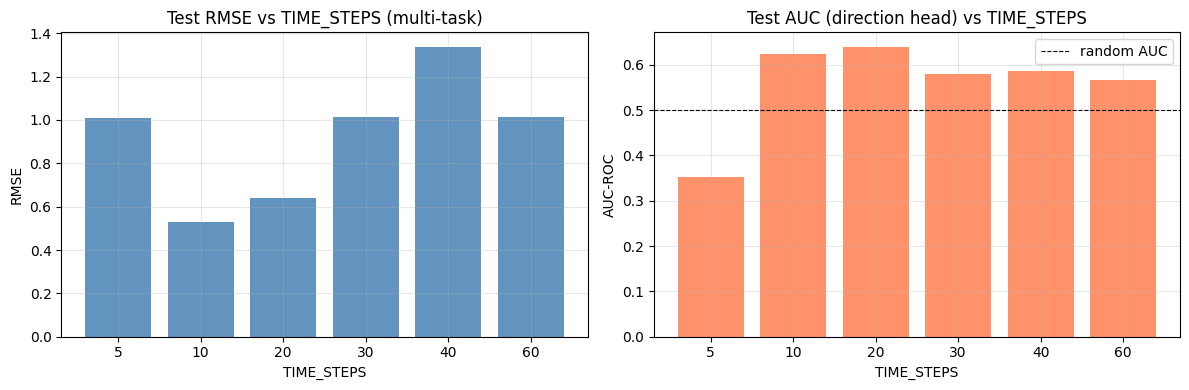

In [22]:
# Sweep TIME_STEPS; same 70/15/15 split, retrain from scratch each time

candidates = [5, 10, 20, 30, 40, 60]
rows = []
n = len(panel)
i_train = int(n * 0.7)
max_ts = max(1, i_train - 2)
print(f"Panel rows={n}, train days={i_train}, max TIME_STEPS allowed={max_ts}\n")
for ts in candidates:
    if ts > max_ts:
        print(f"  skip TIME_STEPS={ts} (need ≤ {max_ts} for this panel)")
        continue
    out = train_eval_multitask(
        panel, FEATURE_COLS, ts, epochs=EPOCHS, batch_size=BATCH_SIZE, alpha=LOSS_ALPHA
    )
    rows.append(
        {
            "requested_ts": ts,
            "effective_ts": out["time_steps"],
            "n_test": out["n_test_sequences"],
            "rmse": out["rmse"],
            "mae": out["mae"],
            "mape": out["mape"],
            "r2": out["r2"],
            "dir_lvl": out["direction_accuracy"],
            "cls_acc": out["cls_accuracy"],
            "cls_f1": out["cls_f1"],
            "cls_auc": out["cls_auc"],
        }
    )

sweep_df = pd.DataFrame(rows)
print(sweep_df.to_string(index=False))

if not sweep_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    x = sweep_df["effective_ts"].astype(str)
    axes[0].bar(x, sweep_df["rmse"], color="steelblue", alpha=0.85)
    axes[0].set_title("Test RMSE vs TIME_STEPS (multi-task)")
    axes[0].set_xlabel("TIME_STEPS")
    axes[0].set_ylabel("RMSE")
    axes[0].grid(True, alpha=0.3)
    axes[1].bar(x, sweep_df["cls_auc"].fillna(0), color="coral", alpha=0.85)
    axes[1].axhline(0.5, color="k", lw=0.8, linestyle="--", label="random AUC")
    axes[1].set_title("Test AUC (direction head) vs TIME_STEPS")
    axes[1].set_xlabel("TIME_STEPS")
    axes[1].set_ylabel("AUC-ROC")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()



=== Latest run (res) ===
Split 70/15/15 | train_end=148 val_end=180 | TIME_STEPS=10 | α=0.5
Sequences: train=138 val=32 test=32
Regression (level): RMSE=0.5108 MAE=0.4387 MAPE=0.62% R²=0.0907
Direction (from ΔClose vs prev): acc=50.00% (excl. flat actual: 50.00%)
Direction (classifier head vs y=1[Δlog p>0]): acc=65.62% F1=0.267 AUC=0.623
Confusion matrix [actual down, up] × [pred down, up]:
[[19  0]
 [11  2]]


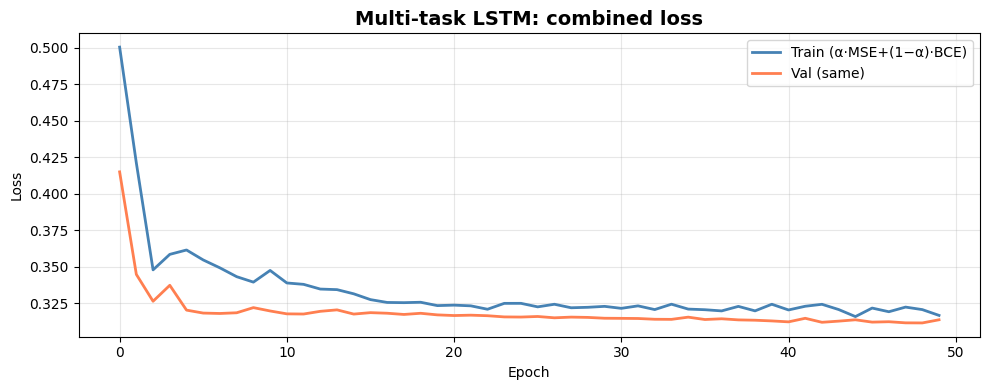

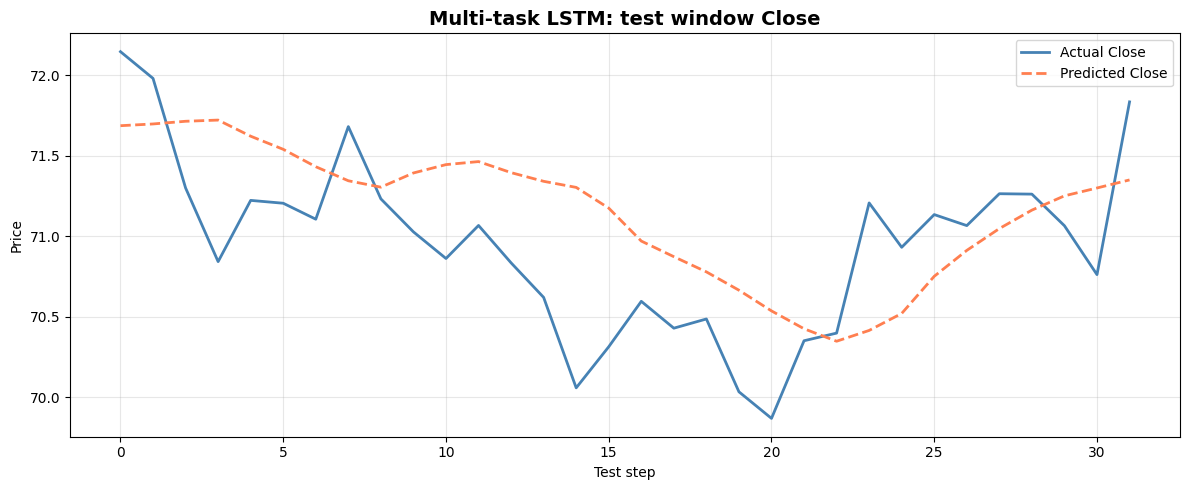


=== TIME_STEPS sweep (test metrics table) ===


,requested_ts,effective_ts,n_test,rmse,mae,mape,r2,dir_lvl,cls_acc,cls_f1,cls_auc
0,20,20,32,0.639075,0.526793,0.745223,-0.423640,0.53125,0.40625,0.577778,0.639676
1,10,10,32,0.527946,0.430284,0.607026,0.028428,0.56250,0.59375,0.000000,0.623482
2,40,40,32,1.337450,1.226299,1.734263,-5.235223,0.43750,0.40625,0.577778,0.587045
3,30,30,32,1.012384,0.901845,1.275987,-2.572621,0.43750,0.59375,0.000000,0.578947
4,60,60,32,1.015333,0.903591,1.278513,-2.593463,0.43750,0.40625,0.577778,0.566802
5,5,5,32,1.008180,0.891297,1.260994,-2.543013,0.46875,0.59375,0.000000,0.352227


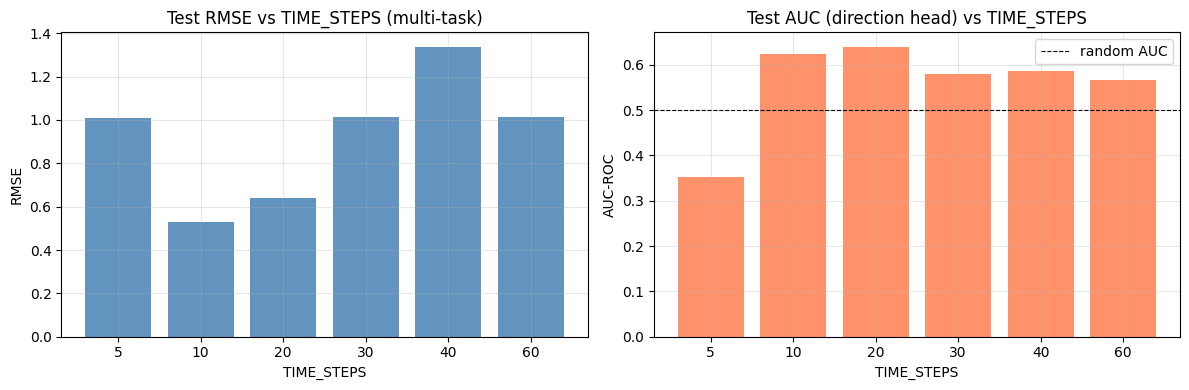

In [23]:
# === Final metrics dashboard (prints + plots) ===
# Assumes you already ran the default run cell (producing `res`) and the TIME_STEPS sweep cell (producing `sweep_df`).

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def _print_dict_metrics(tag: str, d: dict) -> None:
    print(f"\n=== {tag} ===")
    print(
        f"Split 70/15/15 | train_end={d['i_train_end']} val_end={d['i_val_end']} | "
        f"TIME_STEPS={d['time_steps']} | α={d['alpha']}"
    )
    print(f"Sequences: train={d['n_train_sequences']} val={d['n_val_sequences']} test={d['n_test_sequences']}")
    print(
        f"Regression (level): RMSE={d['rmse']:.4f} MAE={d['mae']:.4f} MAPE={d['mape']:.2f}% R²={d['r2']:.4f}"
    )
    print(
        f"Direction (from ΔClose vs prev): acc={d['direction_accuracy']:.2%} "
        f"(excl. flat actual: {d['direction_accuracy_nonzero_actual']:.2%})"
    )
    print(
        f"Direction (classifier head vs y=1[Δlog p>0]): acc={d['cls_accuracy']:.2%} "
        f"F1={d['cls_f1']:.3f} AUC={d['cls_auc']:.3f}"
    )
    print("Confusion matrix [actual down, up] × [pred down, up]:")
    print(d["confusion_matrix"])


if "res" not in globals() or (not isinstance(res, dict)):
    # If you jump straight to the bottom without running the earlier cells, compute a default run now.
    _ts = globals().get("TIME_STEPS", 10)
    _alpha = globals().get("LOSS_ALPHA", 0.5)
    _epochs = globals().get("EPOCHS", 50)
    _bs = globals().get("BATCH_SIZE", 32)
    print("`res` not found — running a default evaluation so metrics appear here.")
    res = train_eval_multitask(panel, FEATURE_COLS, int(_ts), epochs=int(_epochs), batch_size=int(_bs), alpha=float(_alpha))

_print_dict_metrics("Latest run (res)", res)

# Loss curves
plt.figure(figsize=(10, 4))
plt.plot(res["train_losses"], label="Train (α·MSE+(1−α)·BCE)", color="steelblue", linewidth=2)
plt.plot(res["val_losses"], label="Val (same)", color="coral", linewidth=2)
plt.title("Multi-task LSTM: combined loss", fontsize=14, fontweight="bold")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Price plot
plt.figure(figsize=(12, 5))
plt.plot(res["act_price"], label="Actual Close", color="steelblue", linewidth=2)
plt.plot(res["pred_price"], label="Predicted Close", color="coral", linewidth=2, linestyle="--")
plt.title("Multi-task LSTM: test window Close", fontsize=14, fontweight="bold")
plt.xlabel("Test step")
plt.ylabel("Price")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Show sweep summary if present
if "sweep_df" in globals() and isinstance(sweep_df, pd.DataFrame) and (not sweep_df.empty):
    print("\n=== TIME_STEPS sweep (test metrics table) ===")
    display(sweep_df.sort_values(["cls_auc", "rmse"], ascending=[False, True]).reset_index(drop=True))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    x = sweep_df["effective_ts"].astype(str)
    axes[0].bar(x, sweep_df["rmse"], color="steelblue", alpha=0.85)
    axes[0].set_title("Test RMSE vs TIME_STEPS (multi-task)")
    axes[0].set_xlabel("TIME_STEPS")
    axes[0].set_ylabel("RMSE")
    axes[0].grid(True, alpha=0.3)
    axes[1].bar(x, sweep_df["cls_auc"].fillna(0), color="coral", alpha=0.85)
    axes[1].axhline(0.5, color="k", lw=0.8, linestyle="--", label="random AUC")
    axes[1].set_title("Test AUC (direction head) vs TIME_STEPS")
    axes[1].set_xlabel("TIME_STEPS")
    axes[1].set_ylabel("AUC-ROC")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


In [24]:
# === Try to improve performance (rank by validation combined loss; do NOT pick by test) ===
# This runs a small sweep over TIME_STEPS and LOSS_ALPHA.
# We select the best configuration by *validation* minimum loss (combined α·MSE+(1−α)·BCE), then report its test metrics.

import numpy as np
import pandas as pd


def _min_val(losses):
    losses = np.asarray(losses, dtype=float)
    return float(np.nanmin(losses)) if losses.size else float("inf")


time_steps_grid = [5, 10, 20, 30]
alpha_grid = [0.2, 0.5, 0.8]

rows = []
for ts in time_steps_grid:
    for a in alpha_grid:
        out = train_eval_multitask(
            panel,
            FEATURE_COLS,
            ts,
            epochs=EPOCHS,
            batch_size=BATCH_SIZE,
            alpha=a,
        )
        rows.append(
            {
                "time_steps": out["time_steps"],
                "alpha": out["alpha"],
                "val_loss_min": _min_val(out.get("val_losses", [])),
                "rmse": out["rmse"],
                "mae": out["mae"],
                "mape": out["mape"],
                "r2": out["r2"],
                "dir_acc_lvl": out["direction_accuracy"],
                "dir_acc_lvl_nz": out["direction_accuracy_nonzero_actual"],
                "cls_acc": out["cls_accuracy"],
                "cls_f1": out["cls_f1"],
                "cls_auc": out["cls_auc"],
                "n_test": out["n_test_sequences"],
            }
        )

sweep2 = pd.DataFrame(rows).sort_values(["val_loss_min"], ascending=True).reset_index(drop=True)
print("Top configs by validation combined loss (lower is better):")
display(sweep2.head(10))

best = sweep2.iloc[0]
print(
    "\nBest-by-val config:",
    f"TIME_STEPS={int(best.time_steps)}",
    f"alpha={float(best.alpha):.2f}",
    f"val_loss_min={float(best.val_loss_min):.4f}",
)
print(
    "Test metrics for best-by-val:",
    f"RMSE={float(best.rmse):.4f}",
    f"R2={float(best.r2):.4f}",
    f"DirAcc(level)={float(best.dir_acc_lvl):.2%}",
    f"ClsAcc={float(best.cls_acc):.2%}",
    f"AUC={float(best.cls_auc):.3f}",
    f"F1={float(best.cls_f1):.3f}",
)

print(
    "\nNote: if direction F1 stays low, the classifier head may be collapsing to the majority class on this small dataset. "
    "AUC is usually more stable than accuracy/F1 under imbalance and tiny test windows."
)


Epoch [10/50] train=0.534478 val=0.520650 lr=1.00e-03
Epoch [20/50] train=0.529496 val=0.521237 lr=5.00e-04
Early stopping at epoch 24 (best val=0.519946)
Training complete (best checkpoint restored).
Epoch [10/50] train=0.355843 val=0.330325 lr=1.00e-03
Epoch [20/50] train=0.338224 val=0.327958 lr=1.00e-03
Epoch [30/50] train=0.332250 val=0.327482 lr=1.00e-03
Epoch [40/50] train=0.334005 val=0.327156 lr=1.00e-03
Epoch [50/50] train=0.332275 val=0.327979 lr=5.00e-04
Training complete (best checkpoint restored).
Epoch [10/50] train=0.189694 val=0.137457 lr=1.00e-03
Epoch [20/50] train=0.161681 val=0.136551 lr=5.00e-04
Epoch [30/50] train=0.149017 val=0.134513 lr=5.00e-04
Epoch [40/50] train=0.146433 val=0.134943 lr=2.50e-04
Epoch [50/50] train=0.145397 val=0.134955 lr=1.25e-04
Early stopping at epoch 50 (best val=0.134513)
Training complete (best checkpoint restored).
Epoch [10/50] train=0.509852 val=0.504117 lr=1.00e-03
Epoch [20/50] train=0.502174 val=0.500051 lr=1.00e-03
Epoch [30/50

,time_steps,alpha,val_loss_min,rmse,mae,mape,r2,dir_acc_lvl,dir_acc_lvl_nz,cls_acc,cls_f1,cls_auc,n_test
0,30,0.8,0.130262,1.208925,1.093124,1.546353,-4.094427,0.40625,0.40625,0.59375,0.000000,0.412955,32
1,10,0.8,0.130557,0.963399,0.847184,1.198804,-2.235262,0.46875,0.46875,0.59375,0.000000,0.497976,32
2,20,0.8,0.132313,0.939711,0.824459,1.166697,-2.078119,0.46875,0.46875,0.59375,0.000000,0.605263,32
3,5,0.8,0.134513,0.502624,0.442951,0.625333,0.119392,0.50000,0.50000,0.59375,0.000000,0.635628,32
4,10,0.5,0.311614,0.476527,0.390712,0.550519,0.208461,0.56250,0.56250,0.59375,0.000000,0.611336,32
5,30,0.5,0.314196,1.099193,0.982311,1.389830,-3.211577,0.43750,0.43750,0.59375,0.000000,0.425101,32
6,20,0.5,0.323116,0.971578,0.856289,1.211757,-2.290422,0.43750,0.43750,0.40625,0.577778,0.582996,32
7,5,0.5,0.327020,0.443722,0.372938,0.525216,0.313693,0.46875,0.46875,0.65625,0.592593,0.659919,32
8,10,0.2,0.488421,0.504066,0.407426,0.573655,0.114332,0.56250,0.56250,0.43750,0.550000,0.591093,32
9,30,0.2,0.498254,1.224509,1.110897,1.571383,-4.226619,0.43750,0.43750,0.59375,0.000000,0.461538,32



Best-by-val config: TIME_STEPS=30 alpha=0.80 val_loss_min=0.1303
Test metrics for best-by-val: RMSE=1.2089 R2=-4.0944 DirAcc(level)=40.62% ClsAcc=59.38% AUC=0.413 F1=0.000

Note: if direction F1 stays low, the classifier head may be collapsing to the majority class on this small dataset. AUC is usually more stable than accuracy/F1 under imbalance and tiny test windows.


## What data + methods produced these results

**Data used**
- Default path (when `USE_FINBERT_MERGED = True`): `data/processed/merged_for_lstm.csv`.
- The model consumes a **daily panel** (one row per date). In the saved run shown earlier it used:
  - `Close`
  - `avg_sentiment`, `sentiment_std`, `news_volume`, `topic_confidence_mean`
  - `return_lag1`, `rolling_vol_7`
  - `inventory_draw_count`, `production_cut_count` (engineered keyword counts)

**Methods (high level)**
- **Targets (multi-task)**
  - **Regression**: predict next-day `Close` (scaled) with MSE.
  - **Classification**: predict next-day direction label \(y_t = \mathbf{1}[\Delta \log p_{t+1} > 0]\) with `BCEWithLogitsLoss`.
- **Model**: shared LSTM trunk + two heads (linear price head; small MLP → logit for direction head).
- **Loss**: combined \(L = \alpha\,\text{MSE} + (1-\alpha)\,\text{BCE}\). Class imbalance is handled via `pos_weight` on BCE.
- **Split**: chronological **70% / 15% / 15%** train/val/test (no shuffle).
- **Scaling**: `MinMaxScaler` fit on **train only**, applied to val/test.
- **Evaluation**: regression metrics (RMSE/MAE/MAPE/R²); classification metrics (accuracy/F1/AUC + confusion matrix). A separate “direction from predicted level change” accuracy is also reported for interpretability.
